# ESCNN Structural Equivariance Experiments
How does ESCNN enforce structural equivariance when it exports a model?

In [1]:
import torch
import torch.nn as nn

from escnn import gspaces
from escnn import nn as escnn_nn

from functools import partial


class EquivariantCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # symmetry group: rotations by multiples of 90 degrees
        self.r2_act = gspaces.rot2dOnR2(N=4)

        # input: scalar field (image)
        in_type = escnn_nn.FieldType(
            self.r2_act,
            3 * [self.r2_act.trivial_repr]
        )

        # hidden representation
        hidden_type = escnn_nn.FieldType(
            self.r2_act,
            16 * [self.r2_act.regular_repr]
        )

        out_type = escnn_nn.FieldType(
            self.r2_act,
            32 * [self.r2_act.regular_repr]
        )

        self.block1 = escnn_nn.SequentialModule(
            escnn_nn.R2Conv(in_type, hidden_type, kernel_size=5, padding=2),
            escnn_nn.ReLU(hidden_type),
            escnn_nn.PointwiseMaxPool(hidden_type, 2)
        )

        self.block2 = escnn_nn.SequentialModule(
            escnn_nn.R2Conv(hidden_type, out_type, kernel_size=5, padding=2),
            escnn_nn.ReLU(out_type),
            escnn_nn.PointwiseMaxPool(out_type, 2)
        )

        self.gpool = escnn_nn.GroupPooling(out_type)

        self.fc = nn.Linear(32 * 8 * 8, 10)

        self.in_type = in_type

    def evaluate_output_shape(self, input_shape):
        return (input_shape[0], 10)

    def forward(self, x):

        x = escnn_nn.GeometricTensor(x, self.in_type)

        x = self.block1(x)
        x = self.block2(x)

        x = self.gpool(x)

        x = torch.flatten(x.tensor, 1)

        return self.fc(x)

    def export(self):
        return torch.nn.Sequential(
            self.block1.export(),
            self.block2.export(),
            self.gpool.export(),
            nn.Flatten(),
            self.fc
        )

In [2]:
import torchvision.transforms as transforms
import torchvision

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

device = "cuda" if torch.cuda.is_available() else "cpu"

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                    download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=10000,
                                        shuffle=False, num_workers=2)

In [3]:
import torch.nn.functional as F

model = EquivariantCNN()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for x, y in trainloader:

    pred = model(x)

    loss = F.cross_entropy(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [4]:
model.eval()

exported_model = model.export()

In [5]:
exported_model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
  )
  (1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
  )
  (2): MaxPoolChannels(kernel_size=4)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=2048, out_features=10, bias=True)
)

In [6]:
import matplotlib.pyplot as plt

def visualize_conv_kernels(conv, max_kernels=64):
    
    weights = conv.weight.detach().cpu()
    
    kernels = weights.mean(dim=1)
    
    n = min(max_kernels, kernels.shape[0])
    
    cols = 8
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    
    axes = axes.flatten()
    
    for i in range(len(axes)):
        
        if i >= n:
            axes[i].axis('off')
            continue
            
        axes[i].imshow(kernels[i], cmap='RdBu')
        axes[i].axis('off')
    
    plt.show()

In [7]:
exported_model[0][0].weight.shape

torch.Size([64, 3, 5, 5])

In [17]:
test_images, test_labels = next(iter(testloader))
layer0_out = exported_model[0](test_images)
layer1_out = exported_model[1](layer0_out)
layer2_out = exported_model[2](layer1_out)
layer3_out = exported_model[3](layer2_out)
output = exported_model[4](layer3_out)

In [19]:
test_images_rot = torch.rot90(test_images, 2, (-2, -1))
layer0_rot_out = exported_model[0](test_images_rot)
layer1_rot_out = exported_model[1](layer0_rot_out)
layer2_rot_out = exported_model[2](layer1_rot_out)
layer3_rot_out = exported_model[3](layer2_rot_out)
output_rot = exported_model[3](layer3_rot_out)

In [20]:
from HSIC import cka
print(cka(test_images, test_images_rot, kernel="rbf").item())
print(cka(layer0_out, layer0_rot_out, kernel="rbf").item())
print(cka(layer1_out, layer1_rot_out, kernel="rbf").item())
print(cka(layer2_out, layer2_rot_out, kernel="rbf").item())
print(cka(layer3_out, layer3_rot_out, kernel="rbf").item())
print(cka(output, output_rot, kernel="rbf").item())

1.0
0.9999970197677612
0.9999940395355225
1.0
1.0
0.5207648873329163


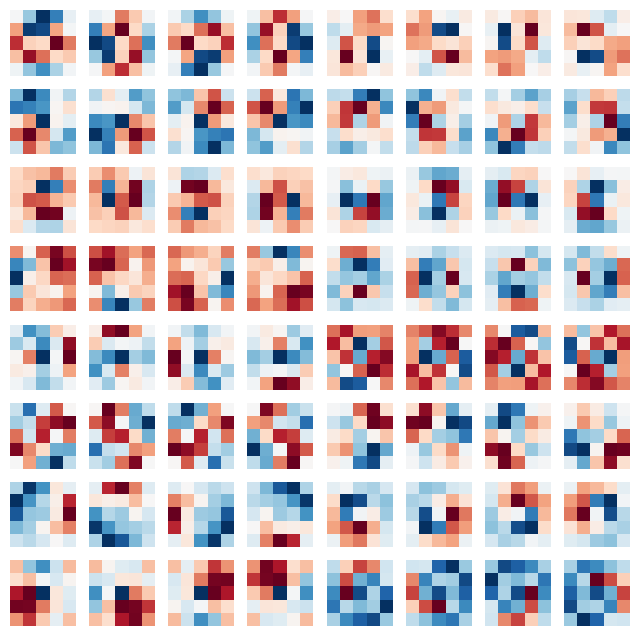

In [11]:
visualize_conv_kernels(exported_model[0][0])

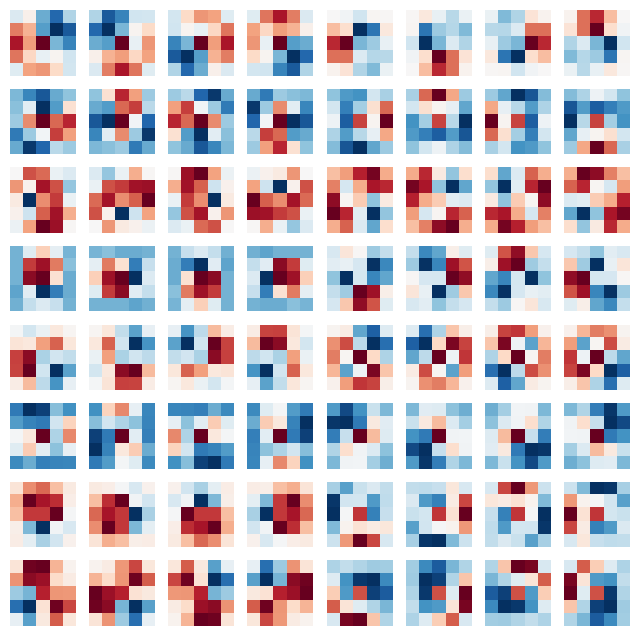

In [12]:
visualize_conv_kernels(exported_model[1][0])


In [21]:
"""
Lie Derivative Equivariance Checker for ESCNN Models
====================================================

Single function: check_equivariance(model, input_tensor)
Returns per-layer equivariance scores for rotation symmetry.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict


def check_equivariance(
    model: nn.Module,
    input_tensor: torch.Tensor,
    epsilon: float = 1e-3,
    threshold: float = 0.05,
) -> Dict[str, dict]:
    """
    Check rotation equivariance at each layer of an ESCNN model
    using the Lie derivative.

    Args:
        model: Your trained model (plain nn.Module or ESCNN module).
               If it expects GeometricTensors, wrap it first — see below.
        input_tensor: (B, C, H, W) batch of test images
        epsilon: Perturbation size for finite differences
        threshold: Score below which a layer counts as equivariant

    Returns:
        Dict mapping layer name -> {
            'score': float,          # lower = more equivariant
            'equivariant': bool,     # score < threshold
            'shape': tuple,          # feature map shape
        }

    Usage:
        # If your model already takes/returns plain tensors:
        results = check_equivariance(model, torch.randn(4, 3, 32, 32))

        # If your model uses ESCNN GeometricTensors, wrap it:
        from escnn.nn import GeometricTensor
        class Wrapper(nn.Module):
            def __init__(self, escnn_model, in_type):
                super().__init__()
                self.m = escnn_model
                self.in_type = in_type
            def forward(self, x):
                return self.m(GeometricTensor(x, self.in_type)).tensor

        results = check_equivariance(Wrapper(escnn_model, in_type), x)

        for name, info in results.items():
            print(f"{name:30s}  score={info['score']:.6f}  {'✓' if info['equivariant'] else '✗'}")
    """
    device = input_tensor.device
    B, C, H, W = input_tensor.shape

    # --- Rotation vector field: V(x,y) = (-y, x) ---
    ys = torch.linspace(-1, 1, H, device=device)
    xs = torch.linspace(-1, 1, W, device=device)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    # Identity grid for grid_sample: (B, H, W, 2)
    identity = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0).expand(B, -1, -1, -1)
    # Rotation perturbation: V = (-y, x)
    rot_field = torch.stack([-grid_y, grid_x], dim=-1).unsqueeze(0)
    perturbed_grid = (identity + epsilon * rot_field).clamp(-1, 1)

    # Warp input along infinitesimal rotation
    input_rotated = F.grid_sample(
        input_tensor, perturbed_grid,
        mode='bilinear', padding_mode='zeros', align_corners=True
    )

    # --- Hook every layer to capture features ---
    features_orig = {}
    features_rot = {}

    def _make_hook(store, name):
        def hook(module, inp, out):
            t = out.tensor if hasattr(out, 'tensor') else out
            if isinstance(t, torch.Tensor) and t.dim() == 4:
                store[name] = t.detach()
        return hook

    hooks = []
    for name, mod in model.named_modules():
        if name:
            hooks.append(mod.register_forward_hook(_make_hook(features_orig, name)))

    model.eval()
    with torch.no_grad():
        model(input_tensor)

    for h in hooks:
        h.remove()

    hooks = []
    for name, mod in model.named_modules():
        if name:
            hooks.append(mod.register_forward_hook(_make_hook(features_rot, name)))

    with torch.no_grad():
        model(input_rotated)

    for h in hooks:
        h.remove()

    # --- Compute Lie derivative score per layer ---
    results = {}
    for name in features_orig:
        if name not in features_rot:
            continue
        f_orig = features_orig[name]
        f_rot = features_rot[name]
        if f_orig.shape != f_rot.shape:
            continue

        # Pushforward: df[V_X] ≈ (f(x+εV) - f(x)) / ε
        pushforward = (f_rot - f_orig) / epsilon

        # Lie derivative on output: L_V[f] = -y·df/dx + x·df/dy
        _, _, Hf, Wf = f_orig.shape
        ys_f = torch.linspace(-1, 1, Hf, device=device)
        xs_f = torch.linspace(-1, 1, Wf, device=device)
        gy, gx = torch.meshgrid(ys_f, xs_f, indexing='ij')

        df_dx = torch.zeros_like(f_orig)
        df_dx[..., 1:-1] = (f_orig[..., 2:] - f_orig[..., :-2]) / 2
        df_dy = torch.zeros_like(f_orig)
        df_dy[..., 1:-1, :] = (f_orig[..., 2:, :] - f_orig[..., :-2, :]) / 2

        lie_deriv = -gy * df_dx + gx * df_dy

        error = lie_deriv - pushforward
        score = (error.pow(2).mean().sqrt() / (f_orig.pow(2).mean().sqrt() + 1e-8)).item()

        results[name] = {
            'score': score,
            'equivariant': score < threshold,
            'shape': tuple(f_orig.shape),
        }

    return results


# --- Quick self-test ---
if __name__ == "__main__":
    # Works with any nn.Module — try with a plain CNN as sanity check
    net = nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
        nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
    )
    x = torch.randn(4, 3, 32, 32)
    results = check_equivariance(net, x)

    print("Layer                           Score      Equivariant?")
    print("-" * 60)
    for name, info in results.items():
        tag = "✓" if info["equivariant"] else "✗"
        print(f"{name:30s}  {info['score']:.6f}   {tag}   {info['shape']}")

Layer                           Score      Equivariant?
------------------------------------------------------------
0                               19.983553   ✗   (4, 16, 32, 32)
1                               19.931040   ✗   (4, 16, 32, 32)
2                               19.517797   ✗   (4, 16, 32, 32)
3                               20.088434   ✗   (4, 16, 32, 32)


In [22]:
check_equivariance(exported_model, test_images)

{'0.0': {'score': 3.854832887649536,
  'equivariant': False,
  'shape': (10000, 64, 32, 32)},
 '0.1': {'score': 3.8802552223205566,
  'equivariant': False,
  'shape': (10000, 64, 32, 32)},
 '0.2': {'score': 3.9205589294433594,
  'equivariant': False,
  'shape': (10000, 64, 16, 16)},
 '0': {'score': 3.9205589294433594,
  'equivariant': False,
  'shape': (10000, 64, 16, 16)},
 '1.0': {'score': 3.6915762424468994,
  'equivariant': False,
  'shape': (10000, 128, 16, 16)},
 '1.1': {'score': 7.134812355041504,
  'equivariant': False,
  'shape': (10000, 128, 16, 16)},
 '1.2': {'score': 6.608109951019287,
  'equivariant': False,
  'shape': (10000, 128, 8, 8)},
 '1': {'score': 6.608109951019287,
  'equivariant': False,
  'shape': (10000, 128, 8, 8)},
 '2': {'score': 5.841076850891113,
  'equivariant': False,
  'shape': (10000, 32, 8, 8)}}